In [1]:
# Cell 1 – Install dependencies
!pip install xgboost lightgbm scikit-learn -q
print("✅ Dependencies installed")

✅ Dependencies installed


In [2]:
# Cell 2 – Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

print("✅ Libraries imported")

✅ Libraries imported


In [3]:
# Cell 3 – Upload your CSV file
from google.colab import files
print("📂 Please upload your CSV file (e.g., data.csv)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filename}")

📂 Please upload your CSV file (e.g., data.csv)


Saving data.csv to data.csv
✅ Uploaded: data.csv


In [4]:
# Cell 4 – Load CSV with correct encoding
df = pd.read_csv(filename, encoding='latin1')
print(f"✅ Data loaded: {len(df):,} rows, {df.shape[1]} columns")
df.head()

✅ Data loaded: 541,909 rows, 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Cell 5 – Data cleaning
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(f"✅ After cleaning: {len(df):,} rows, {df['CustomerID'].nunique():,} unique customers")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

✅ After cleaning: 397,884 rows, 4,338 unique customers
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


Dataset shape: (541909, 8)

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  -

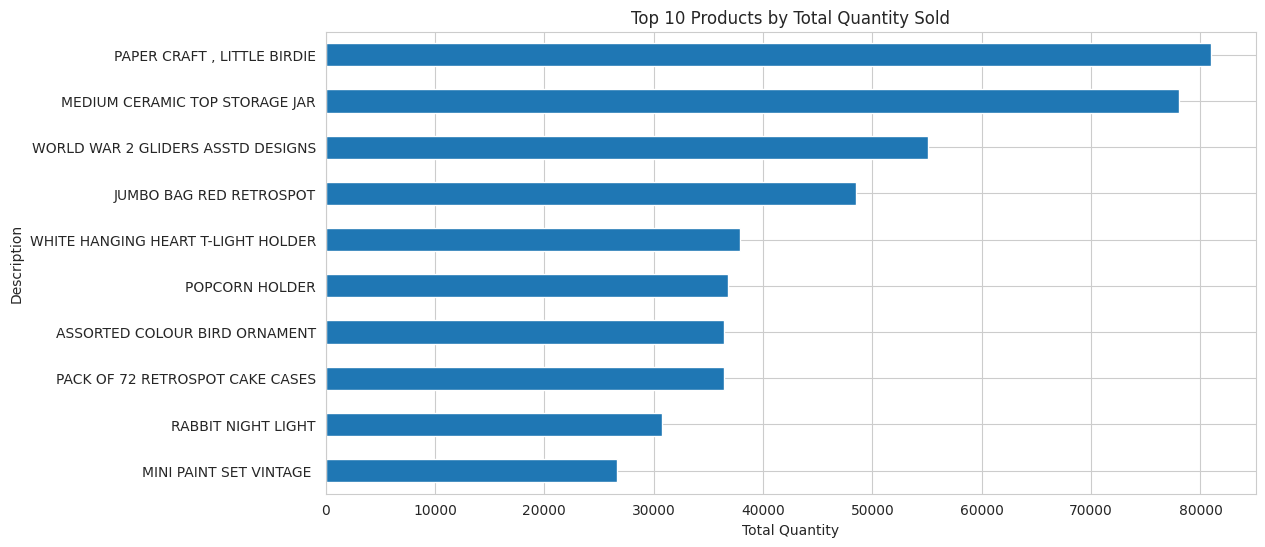

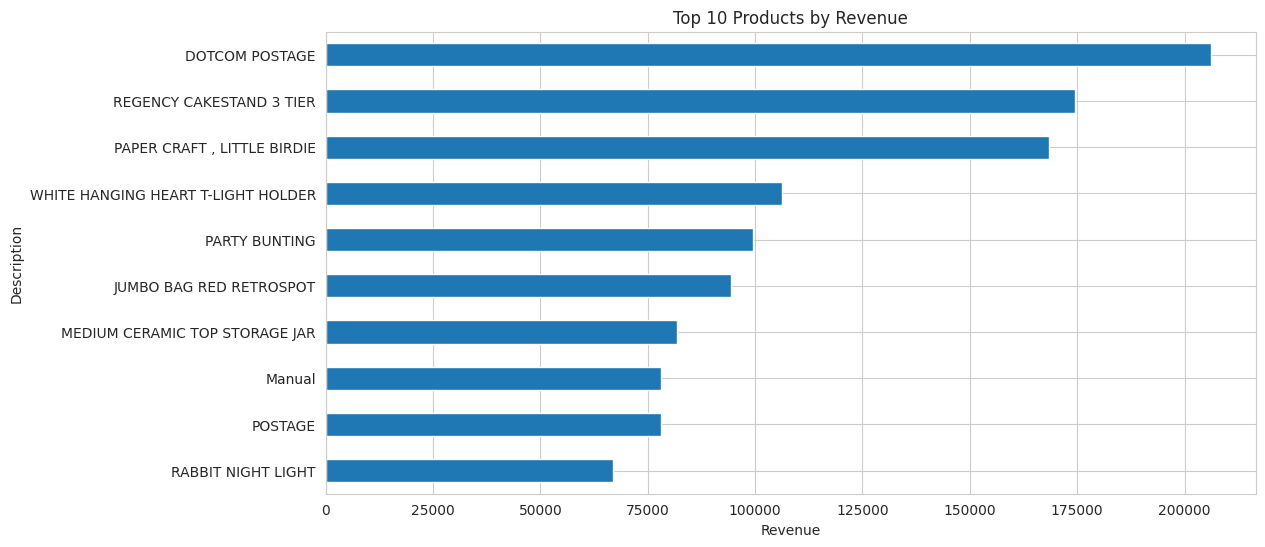

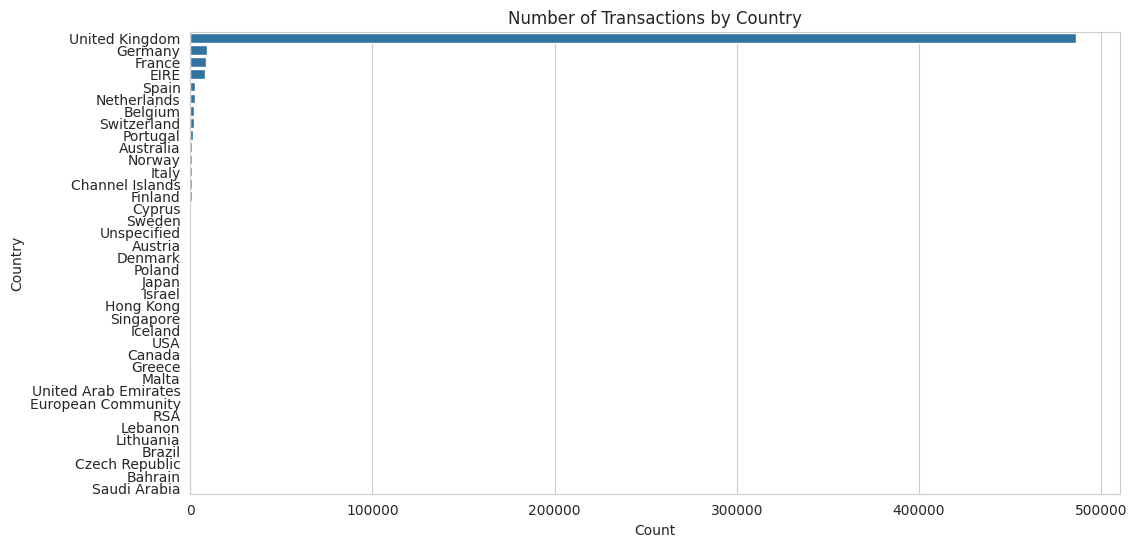

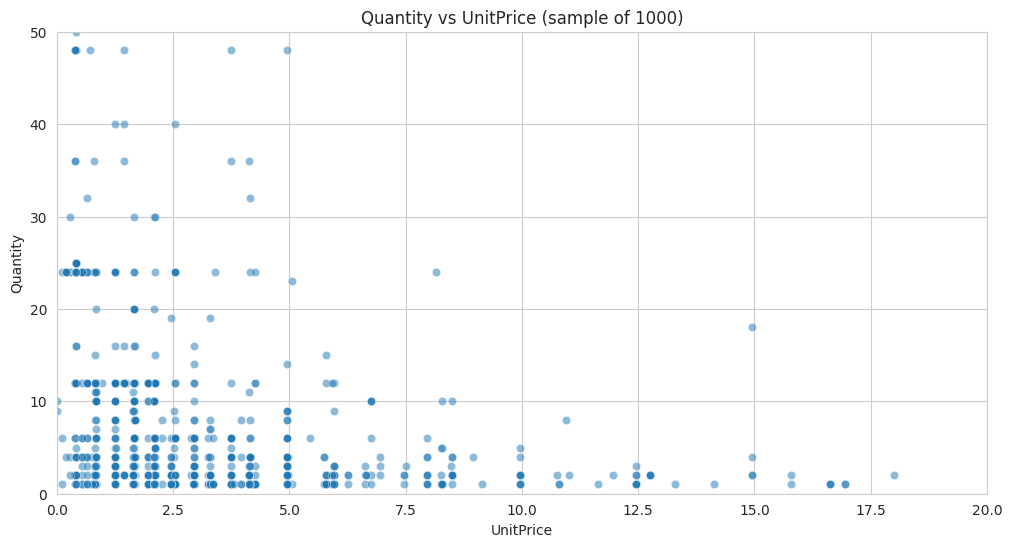

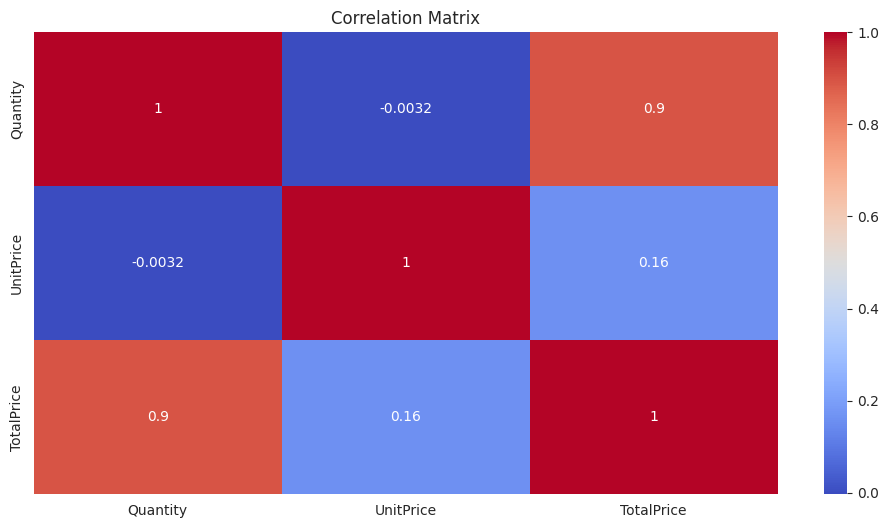

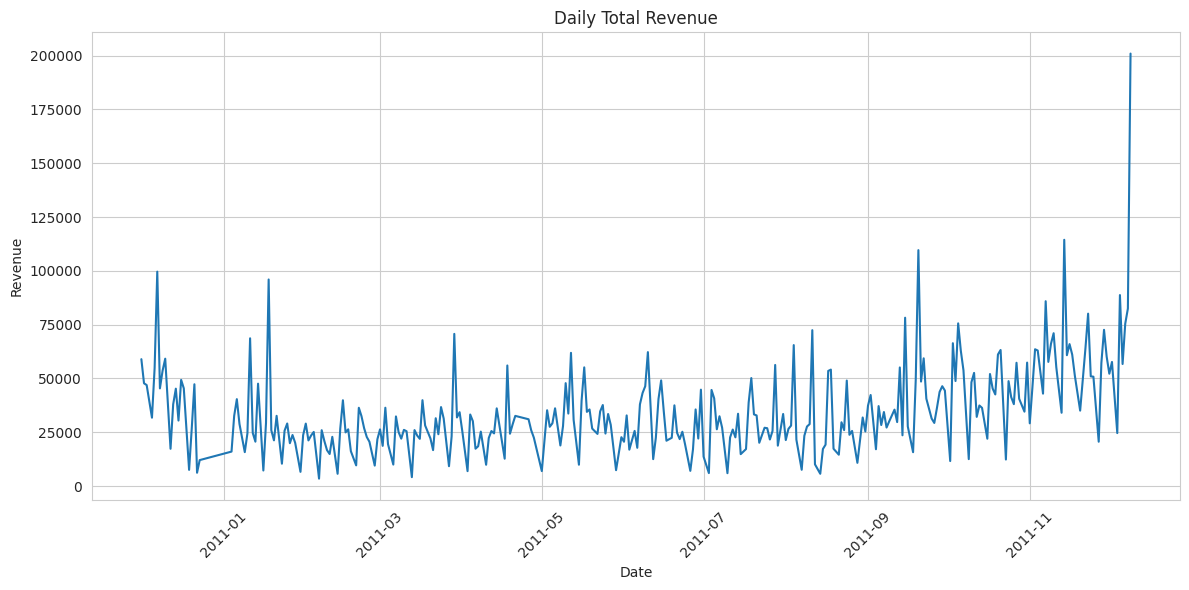

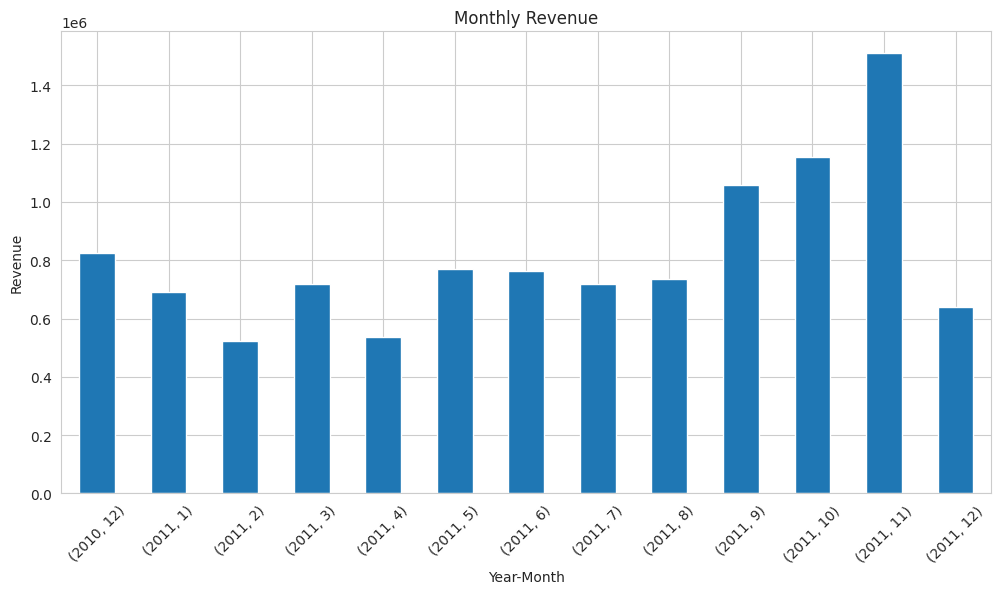

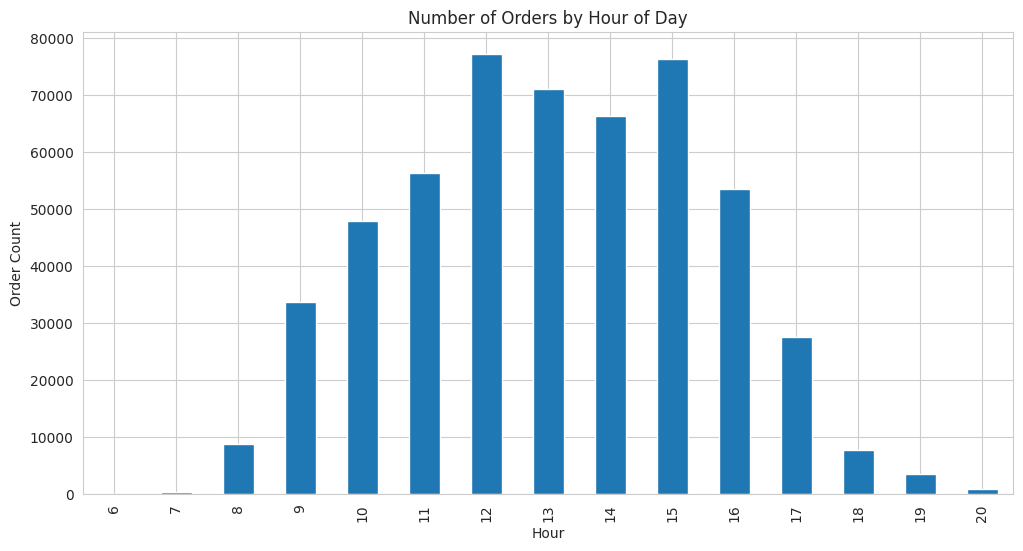

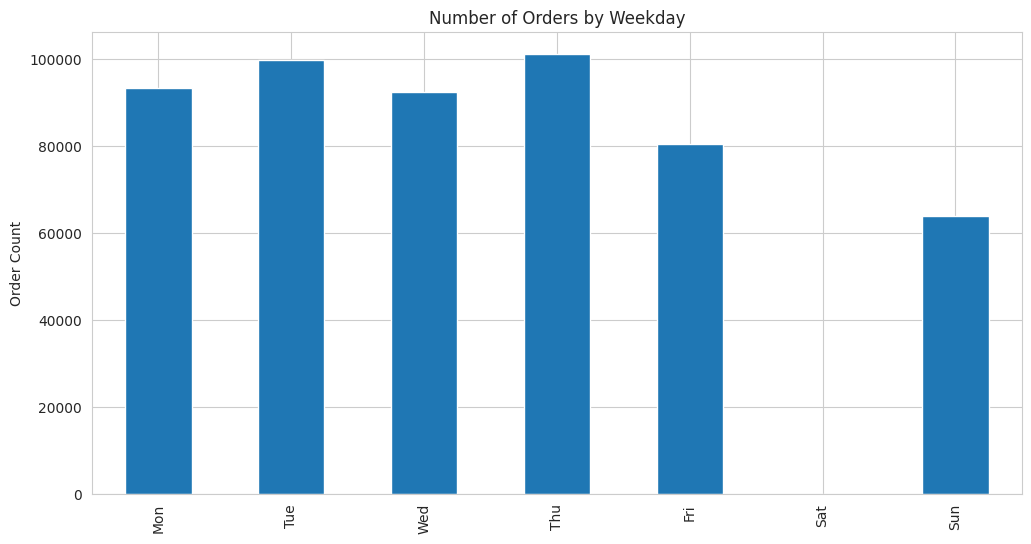


Unique customers: 4339


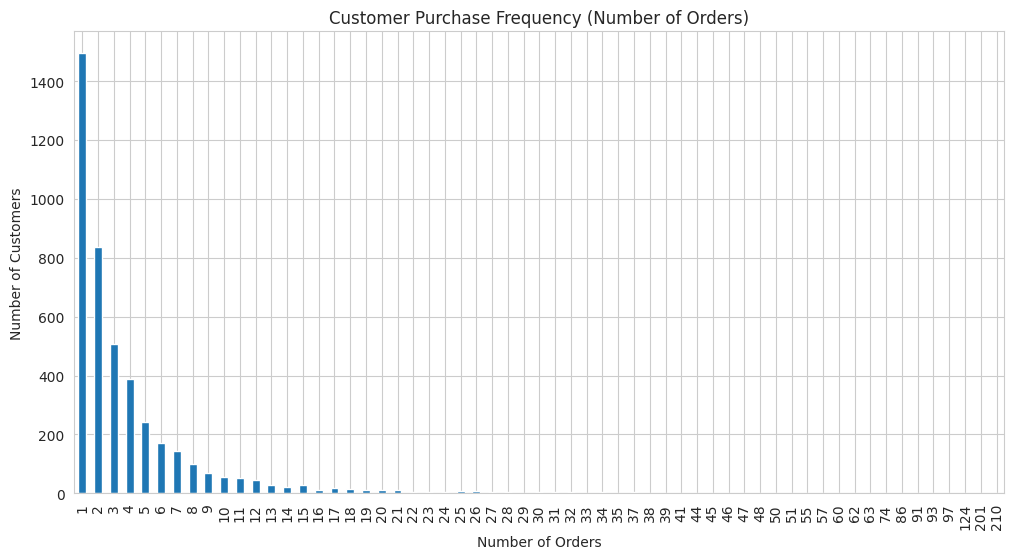

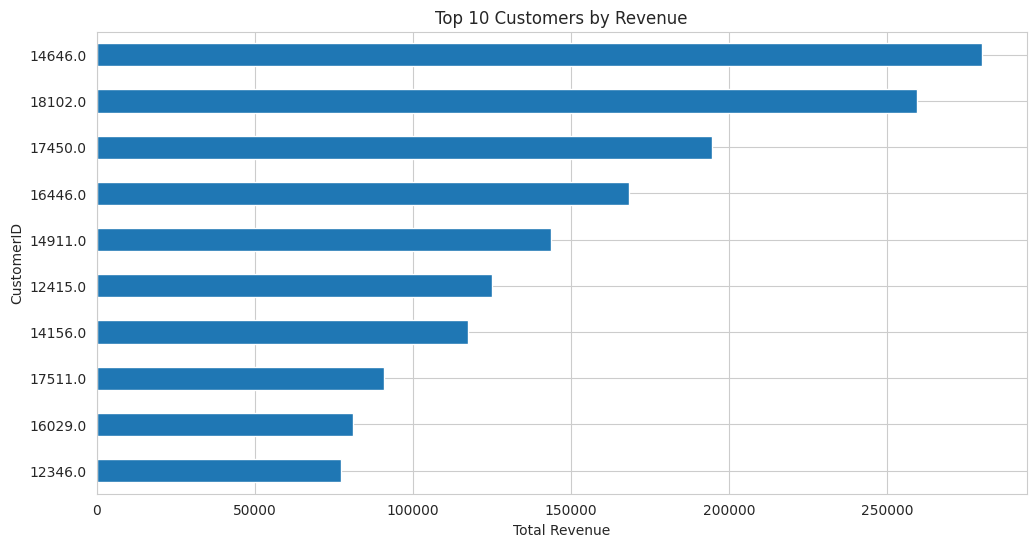


Number of repeat customers: 2845 (65.57%)

Customers who ordered again within 4-30 days: 12
Sample: [12823.0, 13217.0, 13220.0, 13452.0, 13798.0, 14682.0, 15100.0, 15661.0, 15797.0, 16353.0]

Cancellations: 9288


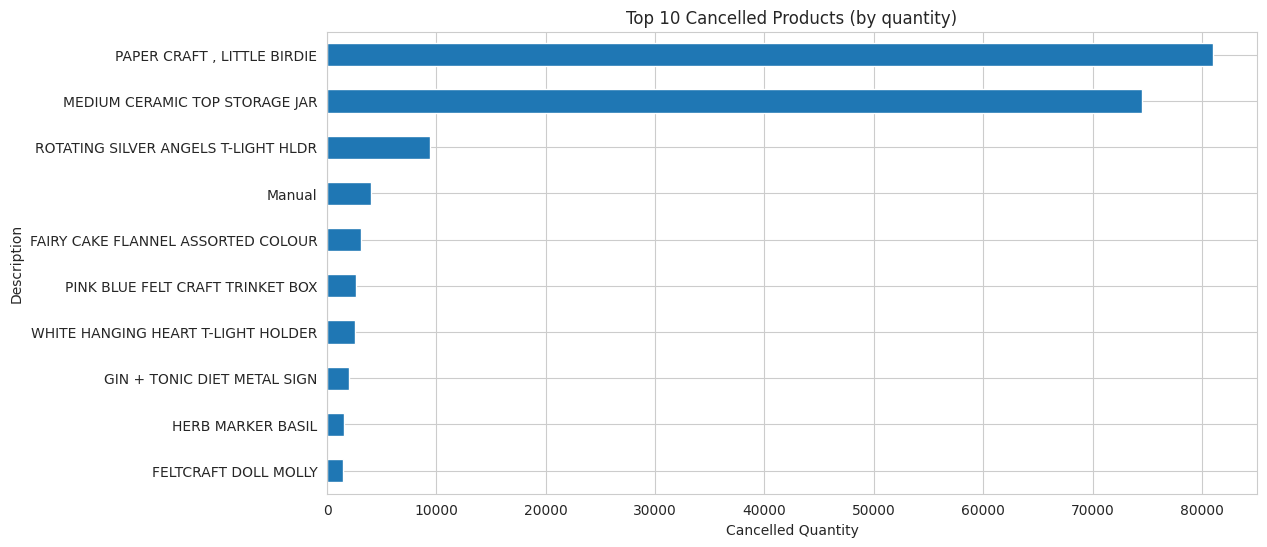

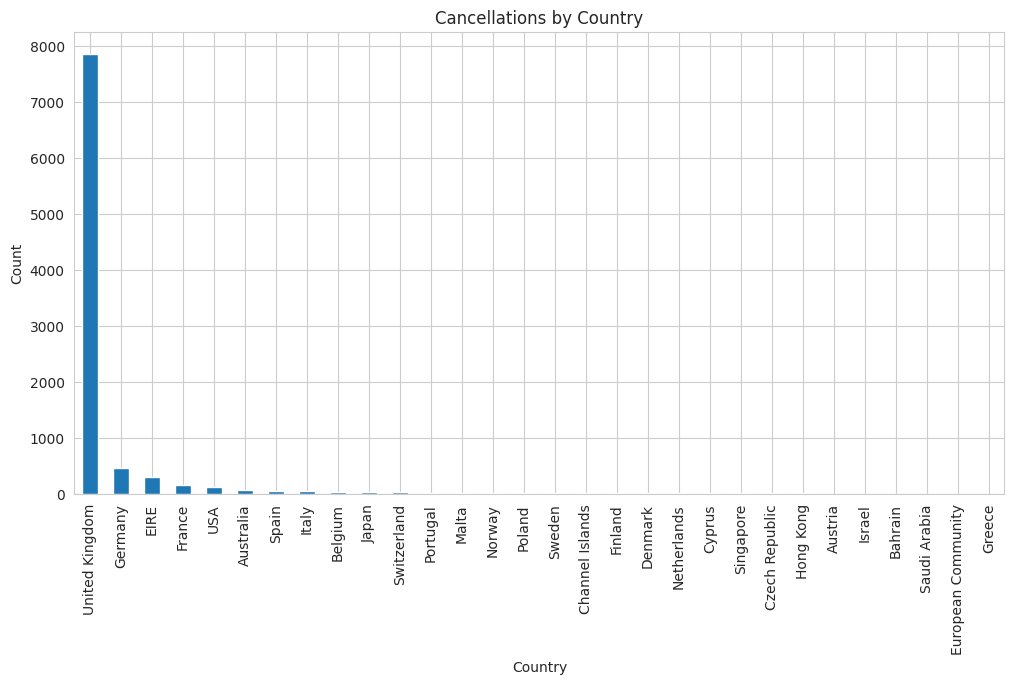

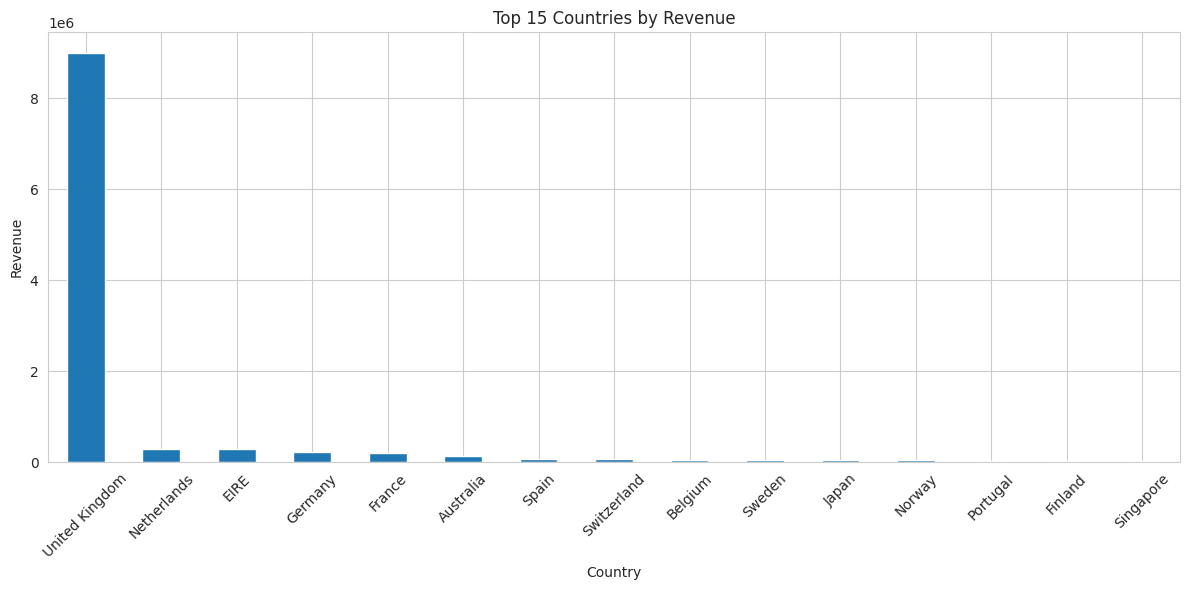


EDA Summary Report
------------------
Total rows: 541909
Sales rows (positive quantity): 531285
Cancellations: 9288
Missing CustomerID: 135080 (24.93%)
Unique customers: 4339
Unique products: 3941
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total revenue (positive sales): £10,644,560.42
Average order value (per invoice): £513.54
Top selling country: United Kingdom with 486286 transactions



In [30]:
# -*- coding: utf-8 -*-
"""
Online Retail EDA
This script performs exploratory data analysis on an online retail dataset.
It includes data cleaning, visualization, and basic customer analytics.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ------------------------------
# 1. Load and Inspect Data
# ------------------------------
# Assuming the CSV file is named 'data.csv' in the working directory.
# If the data is provided as a text block, you can save it to a file first.
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData info:")
df.info()
print("\nSummary statistics:")
print(df.describe(include='all'))

# ------------------------------
# 2. Data Cleaning
# ------------------------------
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create a column for total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Identify cancellations (InvoiceNo starts with 'C')
df['IsCancellation'] = df['InvoiceNo'].astype(str).str.startswith('C')

# Separate sales and cancellations
sales = df[~df['IsCancellation']].copy()
cancellations = df[df['IsCancellation']].copy()

print(f"\nSales transactions: {len(sales)}")
print(f"Cancellations: {len(cancellations)}")

# Check for missing values
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing[missing > 0])

# Handle missing CustomerID (we may drop or keep for some analyses)
# For customer-level analysis, we might exclude rows without CustomerID.
# But for sales trends, we keep them.
df_clean = df.dropna(subset=['CustomerID']).copy()
print(f"\nRows after dropping missing CustomerID: {len(df_clean)}")

# Remove rows with negative or zero Quantity (if not cancellations) – optional
# For revenue calculation, we should keep negatives if they represent returns,
# but for positive sales we filter.
positive_sales = sales[sales['Quantity'] > 0].copy()
print(f"Positive sales rows: {len(positive_sales)}")

# ------------------------------
# 3. Feature Engineering
# ------------------------------
# Extract date parts
positive_sales['Year'] = positive_sales['InvoiceDate'].dt.year
positive_sales['Month'] = positive_sales['InvoiceDate'].dt.month
positive_sales['Day'] = positive_sales['InvoiceDate'].dt.day
positive_sales['Hour'] = positive_sales['InvoiceDate'].dt.hour
positive_sales['Weekday'] = positive_sales['InvoiceDate'].dt.dayofweek  # Monday=0

# Create a date column for grouping
positive_sales['Date'] = positive_sales['InvoiceDate'].dt.date

# ------------------------------
# 4. Univariate Analysis
# ------------------------------



# Top 10 products by quantity sold
top_products = positive_sales.groupby('Description')['Quantity'].sum().nlargest(10)
plt.figure()
top_products.plot(kind='barh')
plt.title('Top 10 Products by Total Quantity Sold')
plt.xlabel('Total Quantity')
plt.gca().invert_yaxis()
plt.show()

# Top 10 products by revenue
top_revenue = positive_sales.groupby('Description')['TotalPrice'].sum().nlargest(10)
plt.figure()
top_revenue.plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.show()

# Country distribution (by number of transactions)
country_counts = positive_sales['Country'].value_counts()
plt.figure()
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Number of Transactions by Country')
plt.xlabel('Count')
plt.show()

# ------------------------------
# 5. Bivariate Analysis
# ------------------------------
# Quantity vs UnitPrice scatter
plt.figure()
sns.scatterplot(data=positive_sales.sample(1000), x='UnitPrice', y='Quantity', alpha=0.5)
plt.title('Quantity vs UnitPrice (sample of 1000)')
plt.xlim(0, 20)
plt.ylim(0, 50)
plt.show()

# Average price by product category? We don't have category, but can use StockCode prefix.

# Correlation matrix for numeric columns
numeric_cols = positive_sales[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
plt.figure()
sns.heatmap(numeric_cols, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# ------------------------------
# 6. Time Series Analysis
# ------------------------------
# Daily sales trend
daily_sales = positive_sales.groupby('Date')['TotalPrice'].sum()
plt.figure()
daily_sales.plot()
plt.title('Daily Total Revenue')
plt.ylabel('Revenue')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Monthly sales (if multiple months are present)
monthly_sales = positive_sales.groupby(['Year', 'Month'])['TotalPrice'].sum()
if len(monthly_sales) > 1:
    plt.figure()
    monthly_sales.plot(kind='bar')
    plt.title('Monthly Revenue')
    plt.ylabel('Revenue')
    plt.xlabel('Year-Month')
    plt.xticks(rotation=45)
    plt.show()

# Hourly order distribution
hourly_orders = positive_sales.groupby('Hour').size()
plt.figure()
hourly_orders.plot(kind='bar')
plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Order Count')
plt.show()



weekday_orders = positive_sales.groupby('Weekday').size()

# Reindex to include all 7 days (0–6), filling missing days with 0
weekday_orders = weekday_orders.reindex(range(7), fill_value=0)

# Now rename the index
weekday_orders.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure()
weekday_orders.plot(kind='bar')
plt.title('Number of Orders by Weekday')
plt.ylabel('Order Count')
plt.show()

# ------------------------------
# 7. Customer Analysis
# ------------------------------
# Number of unique customers
print(f"\nUnique customers: {positive_sales['CustomerID'].nunique()}")

# Customer purchase frequency
customer_freq = positive_sales.groupby('CustomerID')['InvoiceNo'].nunique().value_counts().sort_index()
plt.figure()
customer_freq.plot(kind='bar')
plt.title('Customer Purchase Frequency (Number of Orders)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

# Top 10 customers by revenue
top_customers = positive_sales.groupby('CustomerID')['TotalPrice'].sum().nlargest(10)
plt.figure()
top_customers.plot(kind='barh')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue')
plt.gca().invert_yaxis()
plt.show()

# Repeat customers (ordered more than once)
repeat_customers = positive_sales.groupby('CustomerID')['InvoiceNo'].nunique()
repeat_customers = repeat_customers[repeat_customers > 1]
print(f"\nNumber of repeat customers: {len(repeat_customers)} ({len(repeat_customers)/positive_sales['CustomerID'].nunique()*100:.2f}%)")

# Customers who ordered again within 4-30 days (as per previous query)
# We'll compute the time between first and second order for each customer.
from datetime import timedelta

# Get first and second order dates per customer
customer_orders = positive_sales.groupby('CustomerID')['InvoiceDate'].apply(list).reset_index()
def days_between_first_two(dates):
    if len(dates) < 2:
        return None
    first = min(dates)
    second = sorted(dates)[1]
    return (second - first).days

customer_orders['days_to_second'] = customer_orders['InvoiceDate'].apply(days_between_first_two)
customers_4_30 = customer_orders[(customer_orders['days_to_second'] >= 4) & (customer_orders['days_to_second'] <= 30)]
print(f"\nCustomers who ordered again within 4-30 days: {len(customers_4_30)}")
print("Sample:", customers_4_30['CustomerID'].head(10).tolist())

# ------------------------------
# 8. Cancellation Analysis
# ------------------------------
if not cancellations.empty:
    print(f"\nCancellations: {len(cancellations)}")
    # Most cancelled products
    top_cancelled = cancellations.groupby('Description')['Quantity'].sum().abs().nlargest(10)
    plt.figure()
    top_cancelled.plot(kind='barh')
    plt.title('Top 10 Cancelled Products (by quantity)')
    plt.xlabel('Cancelled Quantity')
    plt.gca().invert_yaxis()
    plt.show()

    # Cancellations by country
    cancel_by_country = cancellations['Country'].value_counts()
    plt.figure()
    cancel_by_country.plot(kind='bar')
    plt.title('Cancellations by Country')
    plt.ylabel('Count')
    plt.show()

# ------------------------------
# 9. Geographic Analysis
# ------------------------------
# Sales by country (revenue)
country_revenue = positive_sales.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(15)
plt.figure()
country_revenue.plot(kind='bar')
plt.title('Top 15 Countries by Revenue')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------
# 10. Additional Insights
# ------------------------------
# Products often bought together? (Market basket analysis - simplified)
# For a full basket analysis, we would use association rule mining.
# Here we just look at co-occurrence of top products.

# Example: Find orders that contain both product A and B.
# We'll skip due to complexity; can be done using pd.crosstab or mlxtend.

# ------------------------------
# 11. Summary Statistics and Export
# ------------------------------
# Generate a summary report as text
summary = f"""
EDA Summary Report
------------------
Total rows: {len(df)}
Sales rows (positive quantity): {len(positive_sales)}
Cancellations: {len(cancellations)}
Missing CustomerID: {df['CustomerID'].isnull().sum()} ({df['CustomerID'].isnull().mean()*100:.2f}%)
Unique customers: {positive_sales['CustomerID'].nunique()}
Unique products: {positive_sales['StockCode'].nunique()}
Date range: {positive_sales['InvoiceDate'].min()} to {positive_sales['InvoiceDate'].max()}
Total revenue (positive sales): £{positive_sales['TotalPrice'].sum():,.2f}
Average order value (per invoice): £{positive_sales.groupby('InvoiceNo')['TotalPrice'].sum().mean():,.2f}
Top selling country: {positive_sales['Country'].value_counts().index[0]} with {positive_sales['Country'].value_counts().iloc[0]} transactions
"""

print(summary)

# Save cleaned data if needed
# positive_sales.to_csv('cleaned_sales.csv', index=False)

In [6]:
# Cell 6 – Add synthetic "Channel" column based on transaction hour
df['Hour'] = df['InvoiceDate'].dt.hour

def assign_channel(hour):
    if 9 <= hour <= 17:
        return np.random.choice(['Web', 'Mobile', 'In-store'], p=[0.70, 0.25, 0.05])
    else:
        return np.random.choice(['Web', 'Mobile', 'In-store'], p=[0.30, 0.65, 0.05])

np.random.seed(42)
df['Channel'] = df['Hour'].apply(assign_channel)
df = df.drop('Hour', axis=1)

print("✅ Channel column added")
print(df['Channel'].value_counts())
df.head()

✅ Channel column added
Channel
Web         272146
Mobile      105859
In-store     19879
Name: count, dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Channel
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,Mobile
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,In-store
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,Mobile
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,Mobile
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,Web


In [7]:
# Cell 7 – Feature engineering functions (including channel proportions)

BASE_FEATURES = [
    "recency", "frequency", "monetary",
    "avg_basket", "avg_items", "total_items",
    "num_products", "days_active", "purchase_rate"
]
CHANNEL_FEATURES = ["pct_web", "pct_mobile", "pct_instore"]
FEATURE_COLS = BASE_FEATURES + CHANNEL_FEATURES

def build_features_from_transactions(transactions_df, cutoff_date):
    snapshot = pd.to_datetime(cutoff_date)
    grouped = transactions_df.groupby('CustomerID')

    features = grouped.agg(
        recency=('InvoiceDate', lambda x: (snapshot - x.max()).days),
        frequency=('InvoiceNo', 'nunique'),
        monetary=('TotalAmount', 'sum'),
        avg_basket=('TotalAmount', 'mean'),
        avg_items=('Quantity', 'mean'),
        total_items=('Quantity', 'sum'),
        num_products=('StockCode', 'nunique'),
        days_active=('InvoiceDate', lambda x: (x.max() - x.min()).days)
    ).reset_index()

    features['purchase_rate'] = features['frequency'] / features['days_active'].replace(0, 1)
    features['purchase_rate'] = features['purchase_rate'].replace([np.inf, -np.inf], 0)

    # Channel proportions
    channel_counts = transactions_df.groupby(['CustomerID', 'Channel']).size().unstack(fill_value=0)
    channel_counts = channel_counts.rename(columns={
        'Web': 'pct_web',
        'Mobile': 'pct_mobile',
        'In-store': 'pct_instore'
    })
    for col in CHANNEL_FEATURES:
        if col not in channel_counts.columns:
            channel_counts[col] = 0

    total_trans = channel_counts.sum(axis=1)
    for col in CHANNEL_FEATURES:
        channel_counts[col] = channel_counts[col] / total_trans

    features = features.merge(channel_counts, on='CustomerID', how='left')
    features[CHANNEL_FEATURES] = features[CHANNEL_FEATURES].fillna(0)
    return features

def build_features_from_input(user_dict):
    """
    For a new customer with aggregated input (no raw transactions).
    """
    recency = user_dict.get('recency', 30)
    frequency = user_dict.get('frequency', 1)
    monetary = user_dict.get('monetary', 100)
    days_active = user_dict.get('days_active', 30)
    avg_items = user_dict.get('avg_items', 3)
    num_products = user_dict.get('num_products', frequency)

    avg_basket = user_dict.get('avg_basket', monetary / max(1, frequency))
    total_items = user_dict.get('total_items', frequency * avg_items)
    purchase_rate = user_dict.get('purchase_rate', frequency / max(1, days_active))

    primary = user_dict.get('primary_channel', 'Web')
    pct_web = 1.0 if primary == 'Web' else 0.0
    pct_mobile = 1.0 if primary == 'Mobile' else 0.0
    pct_instore = 1.0 if primary == 'In-store' else 0.0

    features = {
        'recency': recency,
        'frequency': frequency,
        'monetary': monetary,
        'avg_basket': avg_basket,
        'avg_items': avg_items,
        'total_items': total_items,
        'num_products': num_products,
        'days_active': days_active,
        'purchase_rate': purchase_rate,
        'pct_web': pct_web,
        'pct_mobile': pct_mobile,
        'pct_instore': pct_instore
    }
    return pd.DataFrame([features])[FEATURE_COLS]

print("✅ Feature functions ready")

✅ Feature functions ready


In [8]:
# Cell 8 – Create multi‑cutoff training data (every day as cutoff)
first_date = df['InvoiceDate'].min()
last_date  = df['InvoiceDate'].max()
min_cutoff = first_date + timedelta(days=1)
max_cutoff = last_date - timedelta(days=30)

cutoff_dates = pd.date_range(start=min_cutoff, end=max_cutoff, freq='D')
print(f"Generating training examples for {len(cutoff_dates):,} cutoff dates")

all_training_rows = []
total = len(cutoff_dates)
for i, cutoff in enumerate(cutoff_dates):
    if i % 50 == 0:
        print(f"  Processing cutoff {i+1}/{total} ({cutoff.date()})")

    past = df[df['InvoiceDate'] <= cutoff].copy()
    future = df[
        (df['InvoiceDate'] > cutoff) &
        (df['InvoiceDate'] <= cutoff + timedelta(days=30))
    ].copy()

    if len(past) == 0:
        continue

    features = build_features_from_transactions(past, cutoff)
    target = future.groupby('CustomerID')['TotalAmount'].sum().reset_index()
    target.columns = ['CustomerID', 'future_spend_30d']

    merged = features.merge(target, on='CustomerID', how='left')
    merged['future_spend_30d'] = merged['future_spend_30d'].fillna(0)
    merged['cutoff_date'] = cutoff

    all_training_rows.append(merged)

data = pd.concat(all_training_rows, ignore_index=True)
print(f"✅ Multi‑cutoff training data created: {len(data):,} rows")
print(f"Each customer appears on average {len(data)/data['CustomerID'].nunique():.1f} times")
data.head()

Generating training examples for 343 cutoff dates
  Processing cutoff 1/343 (2010-12-02)
  Processing cutoff 51/343 (2011-01-21)
  Processing cutoff 101/343 (2011-03-12)
  Processing cutoff 151/343 (2011-05-01)
  Processing cutoff 201/343 (2011-06-20)
  Processing cutoff 251/343 (2011-08-09)
  Processing cutoff 301/343 (2011-09-28)
✅ Multi‑cutoff training data created: 839,792 rows
Each customer appears on average 206.5 times


,CustomerID,recency,frequency,monetary,avg_basket,avg_items,total_items,num_products,days_active,purchase_rate,pct_instore,pct_mobile,pct_web,future_spend_30d,cutoff_date
0,12431,0,1,358.25,25.589286,7.642857,107,14,0,1.0,0.000000,0.357143,0.642857,415.70,2010-12-02 08:26:00
1,12433,0,1,1919.14,26.289589,25.369863,1852,73,0,1.0,0.041096,0.191781,0.767123,1867.98,2010-12-02 08:26:00
2,12583,0,1,855.86,42.793000,22.450000,449,20,0,1.0,0.050000,0.550000,0.400000,0.00,2010-12-02 08:26:00
3,12662,0,1,261.48,17.432000,10.466667,157,15,0,1.0,0.133333,0.333333,0.533333,0.00,2010-12-02 08:26:00
4,12748,0,1,4.95,4.950000,1.000000,1,1,0,1.0,0.000000,0.000000,1.000000,4223.18,2010-12-02 08:26:00


In [9]:
# Cell 9 – Train/test split
X = data[FEATURE_COLS]
y = data['future_spend_30d']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train):,} rows | Test size: {len(X_test):,} rows")

Train size: 671,833 rows | Test size: 167,959 rows


In [10]:
# Cell 10 – Train models and select best
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                            subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                              num_leaves=31, random_state=42, verbosity=-1)
}

results = []
best_model = None
best_r2 = -np.inf
best_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_test), 0, None)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{name:20} MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_name = name

print("\n🏆 Best model:", best_name)

Linear Regression    MAE: 228.52  RMSE: 857.50  R2: 0.4506
Ridge                MAE: 228.52  RMSE: 857.50  R2: 0.4506
Random Forest        MAE: 181.83  RMSE: 395.98  R2: 0.8828
Gradient Boosting    MAE: 192.75  RMSE: 447.72  R2: 0.8502
XGBoost              MAE: 186.16  RMSE: 428.75  R2: 0.8626
LightGBM             MAE: 185.72  RMSE: 430.97  R2: 0.8612

🏆 Best model: Random Forest


In [11]:
# Cell 11 – Prediction functions (updated for your requirements)

def predict_existing(customer_id, cutoff_date, data, model, feature_cols):
    """
    Predict for an existing customer at a specific cutoff date.
    Finds the snapshot with cutoff_date <= given cutoff (most recent before or on that date).
    """
    cutoff = pd.to_datetime(cutoff_date)
    # Find all snapshots for this customer with cutoff <= given cutoff
    candidates = data[(data['CustomerID'] == customer_id) & (data['cutoff_date'] <= cutoff)]
    if len(candidates) == 0:
        return {"error": f"No snapshot for customer {customer_id} before or on {cutoff.date()}."}
    # Take the most recent one
    snapshot = candidates.sort_values('cutoff_date', ascending=False).iloc[0]
    features = snapshot[feature_cols].values.reshape(1, -1)
    pred = float(np.clip(model.predict(features)[0], 0, None))
    actual = float(snapshot['future_spend_30d'])
    return {
        "customer_id": int(customer_id),
        "cutoff_date": snapshot['cutoff_date'].strftime('%Y-%m-%d'),
        "predicted_spend": round(pred, 2),
        "actual_spend": round(actual, 2),
        "error": round(abs(pred - actual), 2)
    }

def predict_new_from_transactions(transactions_df, cutoff_date, model, feature_cols):
    """
    Predict for a new customer given raw transactions and a cutoff date.
    transactions_df must have columns: InvoiceDate, Quantity, UnitPrice, Channel.
    Channel can be assigned using the same logic as in Cell 6 if not present.
    """
    # If Channel column missing, assign based on hour (reusing assign_channel)
    if 'Channel' not in transactions_df.columns:
        transactions_df['Hour'] = pd.to_datetime(transactions_df['InvoiceDate']).dt.hour
        transactions_df['Channel'] = transactions_df['Hour'].apply(assign_channel)
        transactions_df = transactions_df.drop('Hour', axis=1)

    # Compute TotalAmount
    transactions_df['TotalAmount'] = transactions_df['Quantity'] * transactions_df['UnitPrice']

    # Add a dummy CustomerID (all rows belong to one new customer)
    transactions_df['CustomerID'] = 999999  # temporary ID

    # Build features using the same function, but only one customer
    features = build_features_from_transactions(transactions_df, cutoff_date)
    # features will have one row (if CustomerID was correctly grouped)
    if len(features) == 0:
        return {"error": "No transactions provided."}
    pred = float(np.clip(model.predict(features[feature_cols])[0], 0, None))
    return {
        "cutoff_date": pd.to_datetime(cutoff_date).strftime('%Y-%m-%d'),
        "predicted_spend": round(pred, 2),
        "num_transactions": len(transactions_df)
    }

# Keep the original predict_new for aggregated input (optional)
def predict_new_aggregated(user_input, model, feature_cols):
    features_df = build_features_from_input(user_input)
    pred = float(np.clip(model.predict(features_df)[0], 0, None))
    return {
        "predicted_spend": round(pred, 2),
        "input_summary": {k: round(v,2) if isinstance(v, (int,float)) else v for k,v in user_input.items()}
    }

print("✅ Prediction functions updated")

✅ Prediction functions updated


In [27]:
# Cell 12 – Demo: Predict for an existing customer with user‑supplied ID and cutoff
print("🔍 Existing customer prediction")
cust_id = int(input("Enter existing Customer ID: "))
cutoff_input = input("Enter cutoff date (YYYY-MM-DD): ")

res = predict_existing(cust_id, cutoff_input, data, best_model, FEATURE_COLS)
print("\nResult:")
print(res)

🔍 Existing customer prediction
Enter existing Customer ID: 13767
Enter cutoff date (YYYY-MM-DD): 2010-12-13

Result:
{'customer_id': 13767, 'cutoff_date': '2010-12-12', 'predicted_spend': 975.9, 'actual_spend': 1286.68, 'error': 310.78}


In [20]:
# Cell 13 – Demo: Predict for a new customer from an uploaded CSV file
print("\n🆕 New customer prediction from raw transactions (CSV upload)")
print("Please upload a CSV file with the customer's transactions.")
print("The CSV must contain at least: InvoiceDate, Quantity, UnitPrice")
print("(Optional columns: TotalAmount, Channel – if present, they will be used)")
print("Date format can be DD-MM-YYYY HH:MM or YYYY-MM-DD HH:MM")

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filename}")

try:
    # Read CSV (keeping all columns)
    new_df = pd.read_csv(filename, encoding='latin1')

    # Parse InvoiceDate with dayfirst=True to handle DD-MM-YYYY
    new_df['InvoiceDate'] = pd.to_datetime(new_df['InvoiceDate'], dayfirst=True, errors='coerce')
    # Drop rows with invalid dates
    new_df = new_df.dropna(subset=['InvoiceDate'])

    # Ensure required columns exist
    required = {'Quantity', 'UnitPrice'}
    if not required.issubset(new_df.columns):
        print(f"❌ CSV must contain columns: {required}")
    else:
        # Compute TotalAmount if not present
        if 'TotalAmount' not in new_df.columns:
            new_df['TotalAmount'] = new_df['Quantity'] * new_df['UnitPrice']
            print("ℹ️ 'TotalAmount' column added (Quantity * UnitPrice).")

        # Add Channel if not present
        if 'Channel' not in new_df.columns:
            # Extract hour
            new_df['Hour'] = new_df['InvoiceDate'].dt.hour
            # Reuse the same assignment function from training
            def assign_channel(hour):
                if 9 <= hour <= 17:
                    return np.random.choice(['Web', 'Mobile', 'In-store'], p=[0.70, 0.25, 0.05])
                else:
                    return np.random.choice(['Web', 'Mobile', 'In-store'], p=[0.30, 0.65, 0.05])
            np.random.seed(42)  # for reproducibility
            new_df['Channel'] = new_df['Hour'].apply(assign_channel)
            new_df = new_df.drop('Hour', axis=1)
            print("ℹ️ 'Channel' column added based on transaction hour.")
        else:
            print("ℹ️ Using existing 'Channel' column.")

        print(f"✅ Loaded {len(new_df)} transactions")
        cutoff = input("Enter cutoff date for prediction (YYYY-MM-DD): ")
        res = predict_new_from_transactions(new_df, cutoff, best_model, FEATURE_COLS)
        print("\nResult:")
        print(res)
except Exception as e:
    print(f"❌ Error reading CSV: {e}")


🆕 New customer prediction from raw transactions (CSV upload)
Please upload a CSV file with the customer's transactions.
The CSV must contain at least: InvoiceDate, Quantity, UnitPrice
(Optional columns: TotalAmount, Channel – if present, they will be used)
Date format can be DD-MM-YYYY HH:MM or YYYY-MM-DD HH:MM


Saving invoice_dataset.csv to invoice_dataset.csv
✅ Uploaded: invoice_dataset.csv
ℹ️ 'TotalAmount' column added (Quantity * UnitPrice).
ℹ️ Using existing 'Channel' column.
✅ Loaded 4 transactions
Enter cutoff date for prediction (YYYY-MM-DD): 2011-10-25

Result:
{'cutoff_date': '2011-10-25', 'predicted_spend': 48.06, 'num_transactions': 4}


In [14]:
# Cell 14 – (Optional) Save the best model
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')
print("✅ Model saved as 'best_model.pkl'")

from google.colab import files
files.download('best_model.pkl')
files.download('feature_cols.pkl')

✅ Model saved as 'best_model.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>